Goal : Spatial Geolocation clustering Using DBSCAN

In [ ]:
import pandas as pd
import numpy as np

In [3]:
dataset = pd.read_csv('../dataset/Crime_Data_from_2020_to_Present.csv')
dataset.head(1)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506


In [4]:
dataset.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='str')

In [5]:
dataset['LOCATION'].nunique()

66567

In [6]:
coords = dataset[
    (dataset['LAT'] != 0) &
    (dataset['LON'] != 0)
]

coords.reset_index(inplace=True)
training_set= np.radians(coords[['LAT' , 'LON']])

In [6]:
training_set.head(2)

,LAT,LON
0,0.594066,-2.065608
1,0.594187,-2.064075


In [7]:
training_set.isna().sum()

LAT    0
LON    0
dtype: int64

In [8]:
coords.shape , training_set.shape

((1002958, 29), (1002958, 2))

In [9]:
training_set.head()

,LAT,LON
0,0.594066,-2.065608
1,0.594187,-2.064075
2,0.593778,-2.064728
3,0.596163,-2.067145
4,0.594843,-2.063206


 From the above operation we determine the location of the Crimes 

In [10]:
# determining the Dense crime area by the Crime Locations
from sklearn.cluster import DBSCAN

# Kilometers
km = 0.1
earths_rad = 6371

db_clusterer = DBSCAN(
    
    # Generic Idea of Hyper parameters ;
    # For Every 100 meters there Must be 14 Crime Locations 
    # inorder to be called the Dense Crime Area
    eps = km/earths_rad ,
    metric='haversine',
    min_samples = 14
)

In [11]:
# Clustering and Label fitting
DBSCAN_labels  = db_clusterer.fit_predict(training_set)

In [12]:
DBSCAN_df = coords.copy()
DBSCAN_df['Cluster_labels'] = DBSCAN_labels

In [13]:
DBSCAN_df.sample(4)

,index,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Cluster_labels
929337,931577,240610012,6/20/2024 0:00,6/17/2024 0:00,1320,6,Hollywood,647,1,440,...,Invest Cont,440.0,NaN,NaN,NaN,1600 VINE ST,NaN,34.0998,-118.3267,321
707619,709856,231205036,1/19/2023 0:00,1/19/2023 0:00,1315,12,77th Street,1245,2,626,...,Invest Cont,626.0,NaN,NaN,NaN,1400 W 68TH ST,NaN,33.9778,-118.3003,296
85905,86194,200217914,11/27/2020 0:00,11/27/2020 0:00,1945,2,Rampart,245,1,220,...,Invest Cont,220.0,NaN,NaN,NaN,2200 W 6TH ST,NaN,34.0601,-118.2761,65
139895,140418,210704636,1/14/2021 0:00,12/28/2020 0:00,1145,7,Wilshire,775,1,440,...,Invest Cont,440.0,NaN,NaN,NaN,4800 ST CHARLES PL,NaN,34.0427,-118.3423,314


### Cluster Evaluation

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

mask = DBSCAN_labels != -1

X = training_set[mask]
y = DBSCAN_labels[mask]

sample_idx = np.random.choice(len(X), size=50000, replace=False)

silhouette_score(X.iloc[sample_idx], y[sample_idx]),davies_bouldin_score(X.iloc[sample_idx], y[sample_idx])


(0.2608742369178439, 0.5779078890474662)

Interpretation : Considering the DBI its a decently Seperated and tight Cluster Formation , hence consider the Clusters

In [15]:
# Total Number Of cluster Fragmentation
DBSCAN_df['Cluster_labels'].nunique()

8847

In [16]:
# Average Area / Cluster 

DBSCAN_df.shape[0] / DBSCAN_df['Cluster_labels'].nunique()

113.36701706793264

In [17]:
# Cluster Value Counts
DBSCAN_df['Cluster_labels'].value_counts(normalize=True).head(10)

# Decent Distribution (High Noise Count (Probably Sparse Region)) 

Cluster_labels
-1       0.065670
 15      0.033267
 7       0.023914
 65      0.010159
 70      0.008685
 3499    0.007755
 43      0.006982
 1       0.005318
 0       0.005129
 130     0.003933
Name: proportion, dtype: float64

### Cluster ranking

higher Areas within a cluster -> higher rank

In [18]:
# remove noise
df = DBSCAN_df[DBSCAN_df["Cluster_labels"] != -1].copy()

# cluster stats
cluster_stats = df.groupby("Cluster_labels").agg(
    count=("Cluster_labels", "size"),
    lat_mean=("LAT", "mean"),
    lon_mean=("LON", "mean"),
    lat_std=("LAT", "std"),
    lon_std=("LON", "std")
)

cluster_stats["area_proxy"] = (
    cluster_stats["lat_std"] * cluster_stats["lon_std"]
)

# avoid division issues
cluster_stats["area_proxy"] = cluster_stats["area_proxy"].replace(0, np.nan)

# density = points per area
cluster_stats["density"] = cluster_stats["count"] / cluster_stats["area_proxy"]

# rank by density (highest = hottest hotspot)
cluster_stats = cluster_stats.sort_values("density", ascending=False)

# add rank
cluster_stats["hotspot_rank"] = np.arange(1, len(cluster_stats) + 1)

cluster_stats.head(10)

,count,lat_mean,lon_mean,lat_std,lon_std,area_proxy,density,hotspot_rank
Cluster_labels,,,,,,,,
5058,1528,34.244000,-118.558297,0.000005,0.000047,2.398448e-10,6.370788e+12,1
4839,1198,34.190408,-118.605900,0.000046,0.000014,6.629340e-10,1.807118e+12,2
359,469,34.197596,-118.457404,0.000019,0.000020,3.889950e-10,1.205671e+12,3
6321,457,34.202703,-118.374502,0.000028,0.000019,5.217091e-10,8.759671e+11,4
2978,180,34.022203,-118.332997,0.000018,0.000018,3.240223e-10,5.555172e+11,5
5123,240,33.944900,-118.406070,0.000006,0.000072,4.619406e-10,5.195473e+11,6
273,242,33.985697,-118.262806,0.000017,0.000034,5.641096e-10,4.289947e+11,7
3500,112,33.717501,-118.282603,0.000009,0.000028,2.678571e-10,4.181333e+11,8
4934,383,34.191290,-118.594190,0.000030,0.000030,9.169822e-10,4.176744e+11,9


In [19]:
# Consists of the Ranks of the clusters by its Density

rank_map = cluster_stats["hotspot_rank"].to_dict()
# rank_map

In [20]:
DBSCAN_df["density_rank"] = DBSCAN_df["Cluster_labels"].map(rank_map)

checking Upon the Data with the Area

In [21]:
DBSCAN_df[['LOCATION' , 'density_rank']].sample(50)

,LOCATION,density_rank
627419,600 S KENMORE AV,686.0
745206,900 S GRAND AV,933.0
173847,12800 VAN NUYS BL,2810.0
435810,7600 CANOGA AV,19.0
822039,1800 PENNSYLVANIA AV,3934.0
227816,WEYMOUTH,3844.0
266513,4300 LOCKWOOD AV,345.0
842635,1000 S BROADWAY,3141.0
816907,9500 BARTEE AV,3134.0
273158,200 WORLD WY,18.0


# Visualisation of the top 5 Crime Hotspot Area

In [22]:
# !python -m pip install geopandas

In [23]:
import geopandas as gpd
from shapely.geometry import Point

In [24]:
# remove noise
df = DBSCAN_df.copy()
df = df[df["Cluster_labels"] != -1].copy()

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["LON"], df["LAT"]),
    crs="EPSG:4326"
)

In [25]:
gdf_proj = gdf.to_crs(epsg=3857)

In [26]:
hotspots = gdf_proj.groupby("Cluster_labels").agg(
    count=("Cluster_labels", "size"),
    geometry=("geometry", lambda x: x.unary_union.convex_hull)
)

hotspots = gpd.GeoDataFrame(hotspots, geometry="geometry", crs=3857)

C:\Users\apsan\AppData\Local\Temp\ipykernel_6008\1909979447.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geometry=("geometry", lambda x: x.unary_union.convex_hull)


In [27]:
hotspots["area_m2"] = hotspots["geometry"].area
hotspots["density"] = hotspots["count"] / hotspots["area_m2"]

hotspots = hotspots.sort_values("density", ascending=False)

In [28]:
top5 = hotspots.head(5).copy()
top5

,count,geometry,area_m2,density
Cluster_labels,,,,
6379,124,POINT (-13168717.275 4037587.032),0.0,inf
6380,195,"LINESTRING (-13180572.8 4057317.555, -13180327...",0.0,inf
6382,126,POINT (-13201456.337 4059485.025),0.0,inf
6384,91,POINT (-13168450.108 4038568.042),0.0,inf
6387,96,"LINESTRING (-13195467.348 4060710.3, -13195378...",0.0,inf


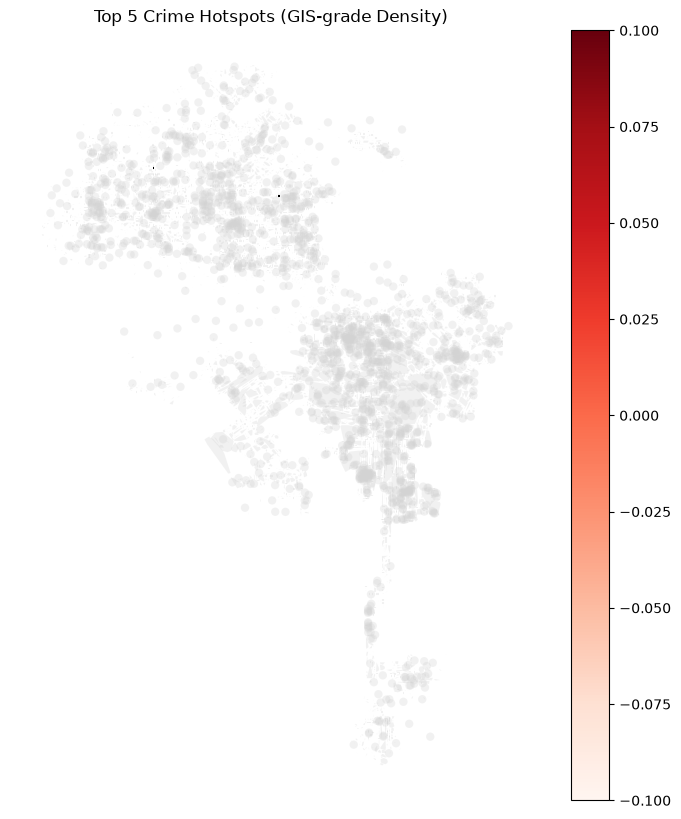

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# plot all hotspot polygons lightly
hotspots.plot(ax=ax, color="lightgrey", edgecolor="none", alpha=0.3)

# highlight top 5
top5.plot(
    ax=ax,
    column="density",
    cmap="Reds",
    legend=True,
    edgecolor="black"
)

ax.set_title("Top 5 Crime Hotspots (GIS-grade Density)")
ax.set_axis_off()

plt.show()

In [30]:
import geopandas as gpd
import folium

# Remove noise
hotspots_clean = hotspots.loc[hotspots.index != -1].copy()

# Top 5 hotspots
top5 = hotspots_clean.sort_values(
    "count",
    ascending=False
).head(5)

# Convert to WGS84 for Folium
top5 = top5.to_crs(4326)

# Map center
center = top5.unary_union.centroid

m = folium.Map(
    location=[center.y, center.x],
    zoom_start=12,
    tiles="CartoDB positron"
)

colors = ["red", "orange", "purple", "blue", "darkred"]

for i, (cluster_id, row) in enumerate(top5.iterrows()):

    color = colors[i % len(colors)]

    # Hotspot polygon
    folium.GeoJson(
        row.geometry,
        style_function=lambda x, c=color: {
            "fillColor": c,
            "color": c,
            "weight": 2,
            "fillOpacity": 0.25
        },
        tooltip=(
            f"Hotspot #{i+1}<br>"
            f"Cluster: {cluster_id}<br>"
            f"Crime Count: {row['count']:,}"
        )
    ).add_to(m)

    centroid = row.geometry.centroid

    # Centroid marker
    folium.CircleMarker(
        location=[centroid.y, centroid.x],
        radius=8,
        color=color,
        fill=True,
        fill_opacity=0.9,
        popup=(
            f"Hotspot #{i+1}<br>"
            f"Cluster: {cluster_id}<br>"
            f"Crime Count: {row['count']:,}"
        )
    ).add_to(m)

    # Permanent label
    folium.Marker(
        [centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                color:black;
                background-color:white;
                border:1px solid black;
                border-radius:4px;
                padding:3px;
                text-align:center;
                white-space:nowrap;
            ">
                #{i+1}<br>
                {row['count']:,}
            </div>
            """
        )
    ).add_to(m)

m.save("top5_crime_hotspots_labeled.html")

print("Saved as top5_crime_hotspots_labeled.html")

Saved as top5_crime_hotspots_labeled.html


C:\Users\apsan\AppData\Local\Temp\ipykernel_6008\2506378961.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = top5.unary_union.centroid


In [31]:
# Saving the Dataset Post Analysis

DBSCAN_df.to_csv('DBSCAN_clustered_ranks.csv')